### Load Dataset

In [194]:
import pandas as pd

df = pd.read_csv('bank_sampah.csv')
df.head()

,id,kode_provinsi,nama_provinsi,bps_kode_kabupaten_kota,bps_nama_kabupaten_kota,bps_kode_kecamatan,bps_nama_kecamatan,bps_kode_desa_kelurahan,bps_desa_kelurahan,kemendagri_kode_kecamatan,kemendagri_nama_kecamatan,kemendagri_kode_desa_kelurahan,kemendagri_nama_desa_kelurahan,nama_unit_bank_sampah,alamat_bank_sampah,tahun
0,1,32,JAWA BARAT,3273,KOTA BANDUNG,3273210,CIBEUNYING KIDUL,3273210002,CICADAS,32.73.14,CIBEUNYING KIDUL,32.73.14.1003,CICADAS,BANK SAMPAH TERATAI INDAH,RW 10,2019
1,2,32,JAWA BARAT,3273,KOTA BANDUNG,3273210,CIBEUNYING KIDUL,3273210002,CICADAS,32.73.14,CIBEUNYING KIDUL,32.73.14.1003,CICADAS,BANK SAMPAH MANDIRI,RW 11,2019
2,3,32,JAWA BARAT,3273,KOTA BANDUNG,3273210,CIBEUNYING KIDUL,3273210003,CIKUTRA,32.73.14,CIBEUNYING KIDUL,32.73.14.1002,CIKUTRA,BANK SAMPAH LESTARI HIJAU,RW 04,2019
3,4,32,JAWA BARAT,3273,KOTA BANDUNG,3273210,CIBEUNYING KIDUL,3273210003,CIKUTRA,32.73.14,CIBEUNYING KIDUL,32.73.14.1002,CIKUTRA,BANK SAMPAH LESTARI HIJAU,RW 07,2019
4,5,32,JAWA BARAT,3273,KOTA BANDUNG,3273210,CIBEUNYING KIDUL,3273210003,CIKUTRA,32.73.14,CIBEUNYING KIDUL,32.73.14.1002,CIKUTRA,BANK SAMPAH DAHLIA,RW 08,2019


### Data Preparation

In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 281 entries, 0 to 280
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   id                              281 non-null    int64 
 1   kode_provinsi                   281 non-null    int64 
 2   nama_provinsi                   281 non-null    object
 3   bps_kode_kabupaten_kota         281 non-null    int64 
 4   bps_nama_kabupaten_kota         281 non-null    object
 5   bps_kode_kecamatan              281 non-null    int64 
 6   bps_nama_kecamatan              281 non-null    object
 7   bps_kode_desa_kelurahan         281 non-null    int64 
 8   bps_desa_kelurahan              281 non-null    object
 9   kemendagri_kode_kecamatan       281 non-null    object
 10  kemendagri_nama_kecamatan       281 non-null    object
 11  kemendagri_kode_desa_kelurahan  281 non-null    object
 12  kemendagri_nama_desa_kelurahan  281 non-null    ob

In [196]:
df.isnull().sum()

id                                0
kode_provinsi                     0
nama_provinsi                     0
bps_kode_kabupaten_kota           0
bps_nama_kabupaten_kota           0
bps_kode_kecamatan                0
bps_nama_kecamatan                0
bps_kode_desa_kelurahan           0
bps_desa_kelurahan                0
kemendagri_kode_kecamatan         0
kemendagri_nama_kecamatan         0
kemendagri_kode_desa_kelurahan    0
kemendagri_nama_desa_kelurahan    0
nama_unit_bank_sampah             0
alamat_bank_sampah                6
tahun                             0
dtype: int64

In [197]:
df['alamat_bank_sampah'] = df['alamat_bank_sampah'].fillna('Alamat tidak tersedia')

print(df.isnull().sum())

id                                0
kode_provinsi                     0
nama_provinsi                     0
bps_kode_kabupaten_kota           0
bps_nama_kabupaten_kota           0
bps_kode_kecamatan                0
bps_nama_kecamatan                0
bps_kode_desa_kelurahan           0
bps_desa_kelurahan                0
kemendagri_kode_kecamatan         0
kemendagri_nama_kecamatan         0
kemendagri_kode_desa_kelurahan    0
kemendagri_nama_desa_kelurahan    0
nama_unit_bank_sampah             0
alamat_bank_sampah                0
tahun                             0
dtype: int64


In [198]:
df.describe()

,id,kode_provinsi,bps_kode_kabupaten_kota,bps_kode_kecamatan,bps_kode_desa_kelurahan,tahun
count,281.000000,281.0,281.0,281.0,2.810000e+02,281.000000
mean,141.000000,32.0,3273.0,3273210.0,3.273210e+09,2022.622776
std,81.261922,0.0,0.0,0.0,1.525757e+00,1.696650
min,1.000000,32.0,3273.0,3273210.0,3.273210e+09,2019.000000
25%,71.000000,32.0,3273.0,3273210.0,3.273210e+09,2021.000000
50%,141.000000,32.0,3273.0,3273210.0,3.273210e+09,2023.000000
75%,211.000000,32.0,3273.0,3273210.0,3.273210e+09,2024.000000
max,281.000000,32.0,3273.0,3273210.0,3.273210e+09,2025.000000


In [199]:
df['bps_desa_kelurahan'].unique()

array(['CICADAS', 'CIKUTRA', 'PASIRLAYUNG', 'SUKAMAJU', 'PADASUKA',
       'SUKAPADA'], dtype=object)

In [200]:
df['bps_desa_kelurahan'].value_counts()

bps_desa_kelurahan
PADASUKA       68
PASIRLAYUNG    68
SUKAMAJU       48
CICADAS        46
CIKUTRA        39
SUKAPADA       12
Name: count, dtype: int64

In [201]:
df.duplicated().sum()

np.int64(0)

### Pemilihan Fitur

In [202]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['bps_desa_kelurahan_encoded'] = le.fit_transform(df['bps_desa_kelurahan'])

In [203]:
X = df.drop(['bps_desa_kelurahan', 'bps_desa_kelurahan_encoded'], axis=1)

In [204]:
X_numeric = df.groupby('bps_desa_kelurahan').agg({
    'id': 'count',
    'tahun': [lambda x: x.max() - x.min() + 1,
              'max'] 
})

X_numeric.columns = ['total_unit', 'durasi_tahun', 'tahun_terakhir']

### Menentukan Jumlah Cluster

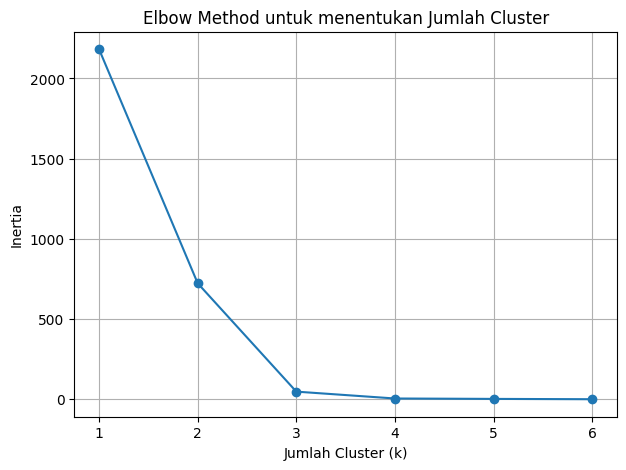

In [205]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_list = []
K_range = range(1, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_numeric)
    inertia_list.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inertia_list, marker='o')
plt.title("Elbow Method untuk menentukan Jumlah Cluster")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

### Modeling

In [206]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters = 3,
    init = "k-means++",
    random_state=42
)

In [207]:
# 1. Masukkan hasil cluster ke dataframe hasil agregasi (X_numeric)
X_numeric['Cluster'] = kmeans.fit_predict(X_numeric)

# 2. Map atau gabungkan kembali ke dataframe asli (df) 
df['Cluster'] = df['bps_desa_kelurahan'].map(X_numeric['Cluster'])

# 3. Cek hasilnya
print("Jumlah baris di df:", len(df))
print("Cluster unik di df:", df['Cluster'].unique())
print(df[['bps_desa_kelurahan', 'nama_unit_bank_sampah', 'Cluster']].head())

Jumlah baris di df: 281
Cluster unik di df: [2 0 1]
  bps_desa_kelurahan      nama_unit_bank_sampah  Cluster
0            CICADAS  BANK SAMPAH TERATAI INDAH        2
1            CICADAS       BANK SAMPAH  MANDIRI        2
2            CIKUTRA  BANK SAMPAH LESTARI HIJAU        2
3            CIKUTRA  BANK SAMPAH LESTARI HIJAU        2
4            CIKUTRA         BANK SAMPAH DAHLIA        2


### Evaluasi

In [208]:
from sklearn.metrics import silhouette_score

# 1. Fitur yang digunakan untuk clustering
# Ambil semua kolom kecuali 'Cluster'
features = X_numeric.drop(columns=['Cluster'])

# 2. Hitung Silhouette Score menggunakan data agregasi
# Parameter 1: Fitur (X), Parameter 2: Label Cluster
score = silhouette_score(features, X_numeric['Cluster'])

print("\n==== SILHOUETTE SCORE ====")
print(f"Silhouette Score: {score:.4f}")


==== SILHOUETTE SCORE ====
Silhouette Score: 0.6743


### Confusion Matrix

In [209]:
from sklearn.metrics import confusion_matrix, classification_report
print("\n==== CONFUSION MATRIX ====")
cm = confusion_matrix(df["bps_desa_kelurahan_encoded"], df["Cluster"])
print(cm)


==== CONFUSION MATRIX ====
[[ 0  0 46  0  0  0]
 [ 0  0 39  0  0  0]
 [68  0  0  0  0  0]
 [68  0  0  0  0  0]
 [ 0  0 48  0  0  0]
 [ 0 12  0  0  0  0]]


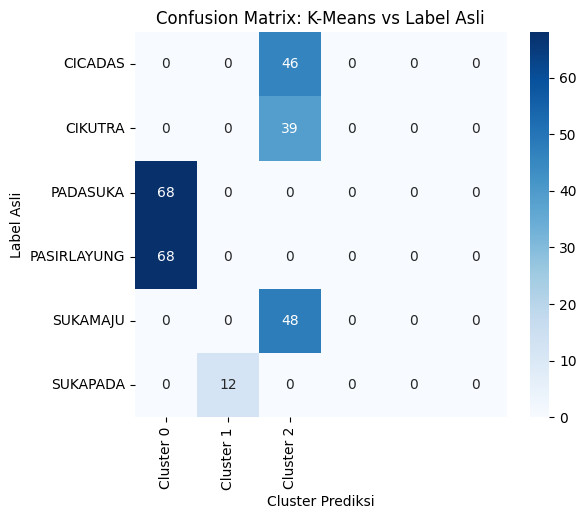

In [210]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=["Cluster 0", "Cluster 1", "Cluster 2"],
    yticklabels=le.classes_
)

plt.title("Confusion Matrix: K-Means vs Label Asli")
plt.xlabel("Cluster Prediksi")
plt.ylabel("Label Asli")
plt.show()

### Visualisasi

<function matplotlib.pyplot.show(close=None, block=None)>

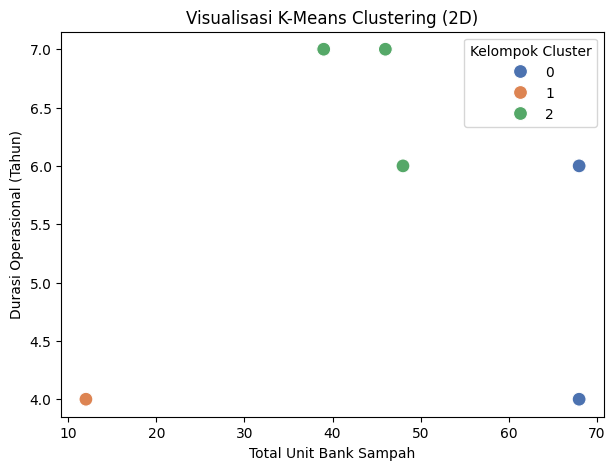

In [211]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=X_numeric,
    x="total_unit",
    y="durasi_tahun",
    hue="Cluster",
    palette="deep",
    s=100
)

plt.title("Visualisasi K-Means Clustering (2D)")
plt.xlabel("Total Unit Bank Sampah")
plt.ylabel("Durasi Operasional (Tahun)")
plt.legend(title="Kelompok Cluster")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

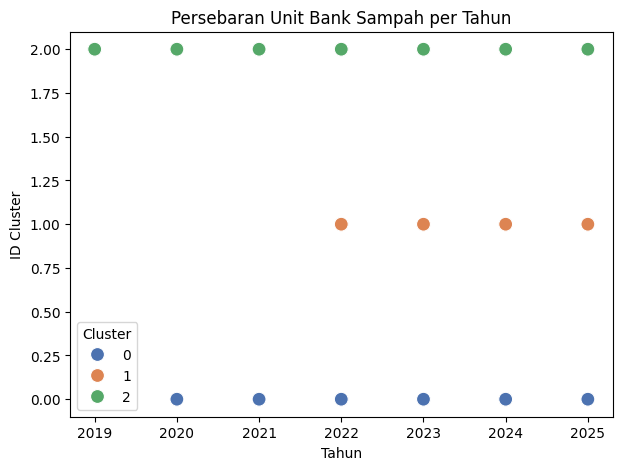

In [212]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df["tahun"],
    y=df["Cluster"],
    hue=df["Cluster"],
    palette="deep",
    s=100
)

plt.title("Persebaran Unit Bank Sampah per Tahun")
plt.xlabel("Tahun")
plt.ylabel("ID Cluster")
plt.show

C:\Users\USER\AppData\Local\Temp\ipykernel_26368\3201244114.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot([x[i], x[i]], [y[i], y[i]], [z.min(), z[i]],


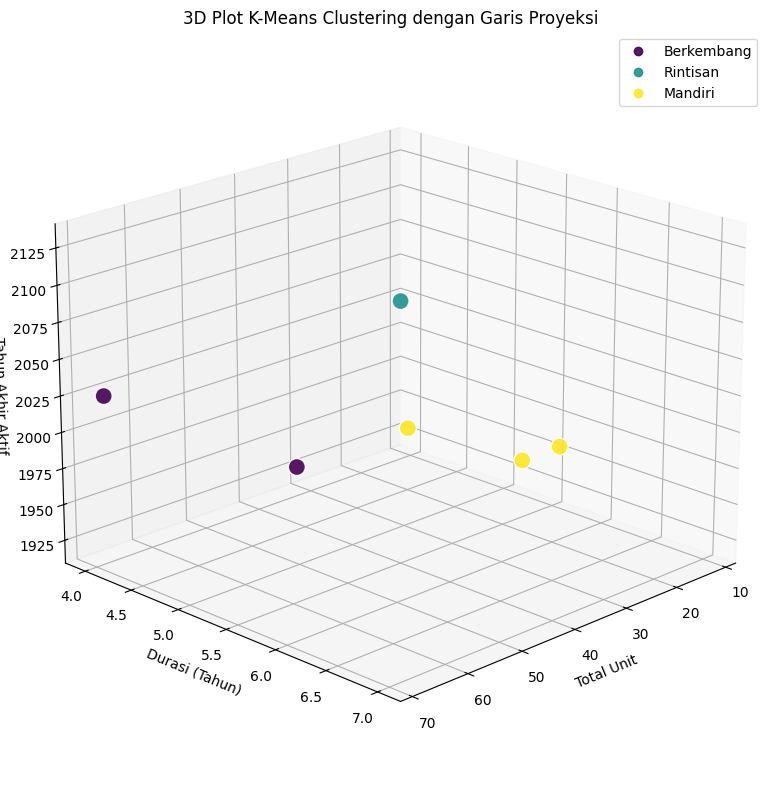

In [213]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Ambil data koordinat
x = X_numeric['total_unit']
y = X_numeric['durasi_tahun']
z = X_numeric['tahun_terakhir']
colors = X_numeric['Cluster']

# Gambar garis proyeksi ke lantai (dasar sumbu Z)
for i in range(len(X_numeric)):
    ax.plot([x[i], x[i]], [y[i], y[i]], [z.min(), z[i]], 
            color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Gambar scatter plot
scatter = ax.scatter(x, y, z, c=colors, s=150, cmap='viridis', alpha=0.9, edgecolors='w')

# Atur sudut pandang
ax.view_init(elev=20, azim=45) 

ax.set_title("3D Plot K-Means Clustering dengan Garis Proyeksi")
ax.set_xlabel("Total Unit")
ax.set_ylabel("Durasi (Tahun)")
ax.set_zlabel("Tahun Akhir Aktif")

# Legend
legend_labels = ["Berkembang", "Rintisan", "Mandiri"]
ax.legend(handles=scatter.legend_elements()[0], labels=legend_labels)

plt.tight_layout()
plt.show()

In [214]:
# Menampilkan daftar kelurahan bdengan clusternya
hasil_akhir = X_numeric[['Cluster']].copy()

# Mari kita beri nama atau label
mapping_nama = {
    0: "Wilayah Berkembang",
    1: "Wilayah Rintisan",
    2: "Wilayah Mandiri"
}
hasil_akhir['Status'] = hasil_akhir['Cluster'].map(mapping_nama)

print("==== HASIL PENGELOMPOKAN KELURAHAN ====")
print(hasil_akhir.sort_values(by='Cluster', ascending=False))

==== HASIL PENGELOMPOKAN KELURAHAN ====
                    Cluster              Status
bps_desa_kelurahan                             
CICADAS                   2     Wilayah Mandiri
CIKUTRA                   2     Wilayah Mandiri
SUKAMAJU                  2     Wilayah Mandiri
SUKAPADA                  1    Wilayah Rintisan
PASIRLAYUNG               0  Wilayah Berkembang
PADASUKA                  0  Wilayah Berkembang


Model Hierarchical Clustering

In [215]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

features = X_numeric.drop(columns=['Cluster'])

agglo = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

cluster_agglo = agglo.fit_predict(features)

score_agglo = silhouette_score(features, cluster_agglo)

print("Silhouette Score Agglomerative:", score_agglo)

Silhouette Score Agglomerative: 0.674275197113069


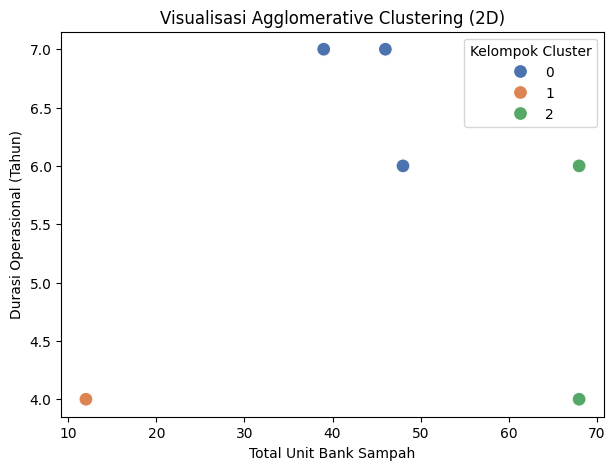

In [216]:
X_numeric['Cluster_Agglo'] = cluster_agglo

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=X_numeric,
    x="total_unit",
    y="durasi_tahun",
    hue="Cluster_Agglo",
    palette="deep",
    s=100
)

plt.title("Visualisasi Agglomerative Clustering (2D)")
plt.xlabel("Total Unit Bank Sampah")
plt.ylabel("Durasi Operasional (Tahun)")
plt.legend(title="Kelompok Cluster")
plt.show()

Model DBSCAN

In [217]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=2,
    min_samples=2
)

cluster_dbscan = dbscan.fit_predict(features)

print("Cluster:", set(cluster_dbscan))

Cluster: {np.int64(0), np.int64(-1)}


In [218]:
if len(set(cluster_dbscan)) > 1:
    score_dbscan = silhouette_score(features, cluster_dbscan)
    print("Silhouette Score DBSCAN:", score_dbscan)

Silhouette Score DBSCAN: 0.5597938697689167


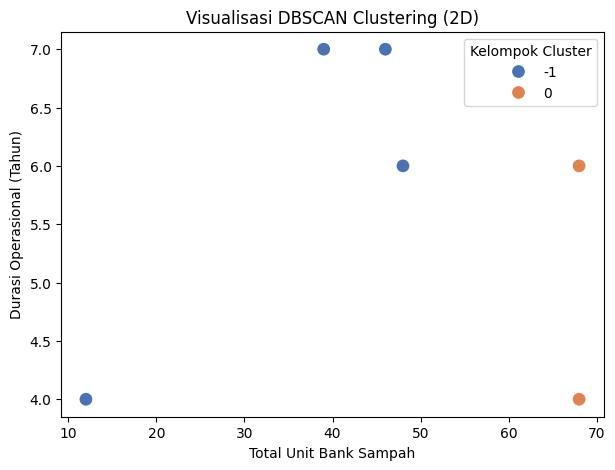

In [219]:
X_numeric['Cluster_DBSCAN'] = cluster_dbscan

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=X_numeric,
    x="total_unit",
    y="durasi_tahun",
    hue="Cluster_DBSCAN",
    palette="deep",
    s=100
)

plt.title("Visualisasi DBSCAN Clustering (2D)")
plt.xlabel("Total Unit Bank Sampah")
plt.ylabel("Durasi Operasional (Tahun)")
plt.legend(title="Kelompok Cluster")
plt.show()

Perbandingan Silhouette Score Antar Model

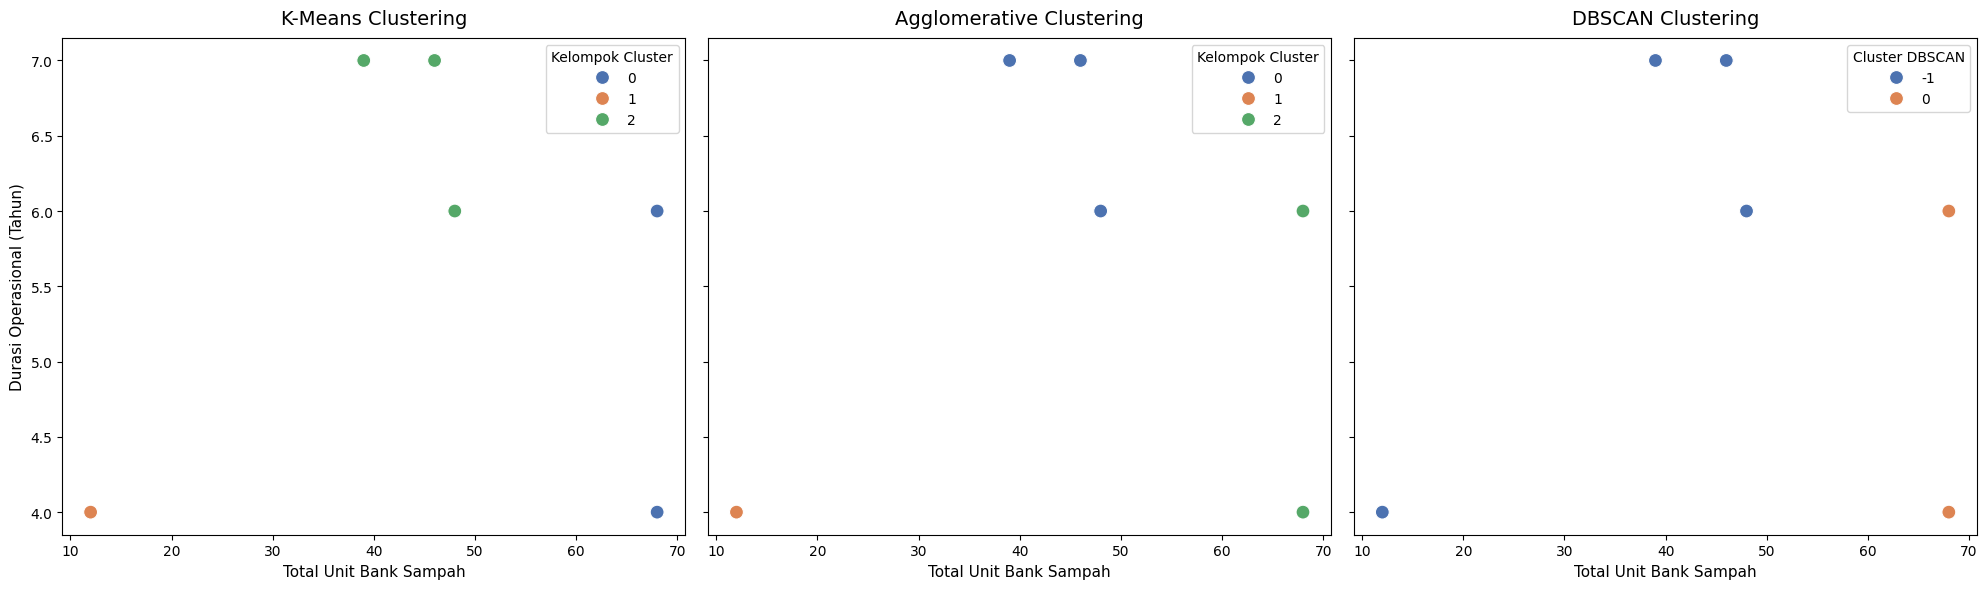

In [220]:
# 1. Pastikan semua kolom cluster sudah dimasukkan ke dalam DataFrame
X_numeric['Cluster_Agglo'] = cluster_agglo
X_numeric['Cluster_DBSCAN'] = cluster_dbscan

# 2. Membuat canvas subplots: 1 baris, 3 kolom
# sharey=True membuat skala sumbu Y seragam di ketiga grafik untuk mempermudah perbandingan
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# --- PLOT 1: K-Means ---
sns.scatterplot(
    data=X_numeric,
    x="total_unit",
    y="durasi_tahun",
    hue="Cluster",
    palette="deep",
    s=100,
    ax=axes[0]
)
axes[0].set_title("K-Means Clustering", fontsize=14, pad=10)
axes[0].set_xlabel("Total Unit Bank Sampah", fontsize=11)
axes[0].set_ylabel("Durasi Operasional (Tahun)", fontsize=11)
axes[0].legend(title="Kelompok Cluster")

# --- PLOT 2: Agglomerative Clustering ---
sns.scatterplot(
    data=X_numeric,
    x='total_unit',
    y='durasi_tahun',
    hue='Cluster_Agglo',
    palette="deep",
    s=100,
    ax=axes[1]
)
axes[1].set_title("Agglomerative Clustering", fontsize=14, pad=10)
axes[1].set_xlabel("Total Unit Bank Sampah", fontsize=11)
axes[1].set_ylabel("") # Dikosongkan karena sudah diwakili sumbu Y plot pertama
axes[1].legend(title="Kelompok Cluster")

# --- PLOT 3: DBSCAN ---
sns.scatterplot(
    data=X_numeric,
    x='total_unit',
    y='durasi_tahun',
    hue='Cluster_DBSCAN',
    palette="deep",
    s=100,
    ax=axes[2]
)
axes[2].set_title("DBSCAN Clustering", fontsize=14, pad=10)
axes[2].set_xlabel("Total Unit Bank Sampah", fontsize=11)
axes[2].set_ylabel("") # Dikosongkan karena sudah diwakili sumbu Y plot pertama
axes[2].legend(title="Cluster DBSCAN")

# 3. Mengatur tata letak plot agar rapi dan tidak tumpang tindih
plt.tight_layout()

# 4. Tampilkan grafik hasil gabungan
plt.show()

In [221]:
hasil = []

# KMeans
km = KMeans(n_clusters=3, random_state=42, n_init=10)
label_km = km.fit_predict(features)

hasil.append([
    "K-Means",
    silhouette_score(features, label_km)
])

# Agglomerative
agg = AgglomerativeClustering(n_clusters=3)
label_agg = agg.fit_predict(features)

hasil.append([
    "Agglomerative",
    silhouette_score(features, label_agg)
])

# DBSCAN
dbs = DBSCAN(eps=2, min_samples=2)
label_dbs = dbs.fit_predict(features)

hasil.append([
    "DBSCAN",
    silhouette_score(features, label_dbs)
])

hasil_df = pd.DataFrame(
    hasil,
    columns=["Model", "Silhouette Score"]
)

print(hasil_df.sort_values(
    by="Silhouette Score",
    ascending=False
))

           Model  Silhouette Score
0        K-Means          0.674275
1  Agglomerative          0.674275
2         DBSCAN          0.559794
